# Impact function v2: short bars, zero-origin curves and temporal stability

This notebook addresses the impact function before using an impact residual as an alpha feature. It deliberately separates:

1. contemporaneous impact measurement;
2. the functional form of the conditional mean;
3. temporal calibration and scale collapse;
4. future-return prediction, which is not performed here.

The cache excludes June–August 2026 so those months remain an untouched alpha holdout.

## Model definition

For each non-overlapping bar:

$$
z_t=\frac{Q_t^{signed}}{Q_t^{gross}},\qquad
a_t=\frac{Q_t^{gross}}{\overline V_{t,24h}},\qquad
y_t=\frac{\operatorname{sign}(Q_t^{signed})r_t}{\sigma_{t,24h}}.
$$

The proposed impact object is:

$$
E[y_t\mid z_t,a_t,\text{side}]=f_{\pm}(|z_t|,a_t).
$$

`normalised_net_flow` remains available as the one-dimensional academic-style axis:

$$
x_t=\frac{|Q_t^{signed}|}{\overline V_{t,24h}}=|z_t|a_t.
$$

All trailing quantities exclude the current bar. The buy and sell branches are estimated separately but constrained to pass through a common zero origin.

In [1]:
from pathlib import Path
from datetime import datetime, timezone
import json
import math
import os

os.environ.setdefault('MPLCONFIGDIR', '/tmp/alpha-search-matplotlib')
Path(os.environ['MPLCONFIGDIR']).mkdir(parents=True, exist_ok=True)

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
from IPython.display import Markdown, display
get_ipython().run_line_magic('matplotlib', 'inline')
pl.Config.set_tbl_rows(100)
pl.Config.set_tbl_cols(20)

REPO = Path('/Users/petermillington/Research/market-impact-research')
SHARED = REPO / 'shared-data'
CACHE_ROOT = SHARED / 'features' / 'alpha' / 'symbol=BTCUSDT' / 'impact_research_v2'

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'figure.dpi': 115, 'axes.spines.top': False, 'axes.spines.right': False})
BUY, SELL = '#13795b', '#c2413b'

## Manual controls

In [2]:
BAR_KIND = 'event'                 # 'event' or 'time'
EVENTS_PER_BAR = 200               # initially 200, 500, 1_000; optionally 50 or 100
TIME_BAR_SIZE = '1m'               # 30s, 1m, 2m, 5m when built
X_DEFINITION = 'normalised_net_flow' # 'normalised_net_flow' or 'relative_imbalance'
CURVE_BINS = 30
SURFACE_IMBALANCE_BINS = 10
SURFACE_ACTIVITY_BINS = 6
DEVELOPMENT_END = '2023-01-01'     # fit through December 2022
VALIDATION_END = '2025-01-01'      # 2023-24 validation; 2025-May26 is later/exposed
DISPLAY_X_UPPER_QUANTILE = 0.999
MODEL_COMPARISON_TAIL = 0.95       # frozen development quantile for the tail chart

assert BAR_KIND in {'event', 'time'}
assert X_DEFINITION in {'relative_imbalance', 'normalised_net_flow'}
assert MODEL_COMPARISON_TAIL in {0.0, 0.80, 0.90, 0.95}
construction = f'event_{EVENTS_PER_BAR}' if BAR_KIND == 'event' else f'time_{TIME_BAR_SIZE}'
CACHE_PATH = CACHE_ROOT / construction / 'part-000.parquet'
if not CACHE_PATH.exists():
    command = (
        f"./shared-methodology/.venv/bin/python alpha-search/scripts/build_impact_research_bars.py "
        f"--shared-data-root ./shared-data "
        + (f"--event-sizes {EVENTS_PER_BAR} --time-bars" if BAR_KIND == 'event'
           else f"--event-sizes --time-bars {TIME_BAR_SIZE}")
    )
    raise FileNotFoundError(f'{CACHE_PATH} is not built. Run:\n\n{command}')

## Coverage and bar-duration atlas

{'cache_version': 'impact_research_v2',
 'symbol': 'BTCUSDT',
 'event_rule': 'timestamp_direction_v1',
 'shared_data_root': '/Volumes/Crypto Research Data/market-impact-research/shared-data',
 'data_fingerprint': 'd9713389b4df7c42441eec4f417284f3957c376024ad727d7860390315029139',
 'coverage': {'months': 81,
  'first_month': '2019-09',
  'last_month': '2026-05',
  'missing_months': [],
  'fill_rows': 7697264050,
  'event_rows': 2422612186,
  'source_bytes': 66210450466,
  'canonical_bytes': 38154728414,
  'event_bytes': 30679068859},
 'holdout_months_excluded': ['2026-06', '2026-07', '2026-08'],
 'event_bar_sizes': [200, 500, 1000],
 'time_bars': ['1m', '2m', '30s', '5m'],
 'trailing_window': '1d',
 'impact_axes': {'relative_imbalance': 'abs(signed_imbalance) / gross_volume',
  'relative_activity': 'gross_volume / preceding_24h_gross_volume',
  'normalised_net_flow': 'abs(signed_imbalance) / preceding_24h_gross_volume',
  'normalised_response': 'side_aligned_bar_return / preceding_24h_r

year,bars,p10_minutes,median_minutes,p90_minutes,median_events
i32,u32,f64,f64,f64,f64
2019,71891,0.171,1.30945,5.627167,200.0
2020,711076,0.095267,0.51555,1.6049,200.0
2021,2690775,0.0402,0.157517,0.397483,200.0
2022,2615994,0.033733,0.13925,0.4423,200.0
2023,1754298,0.040883,0.224183,0.653817,200.0
2024,1923979,0.04455,0.203383,0.595267,200.0
2025,1677767,0.05165,0.2357,0.6711,200.0
2026,667280,0.049417,0.224933,0.731017,200.0


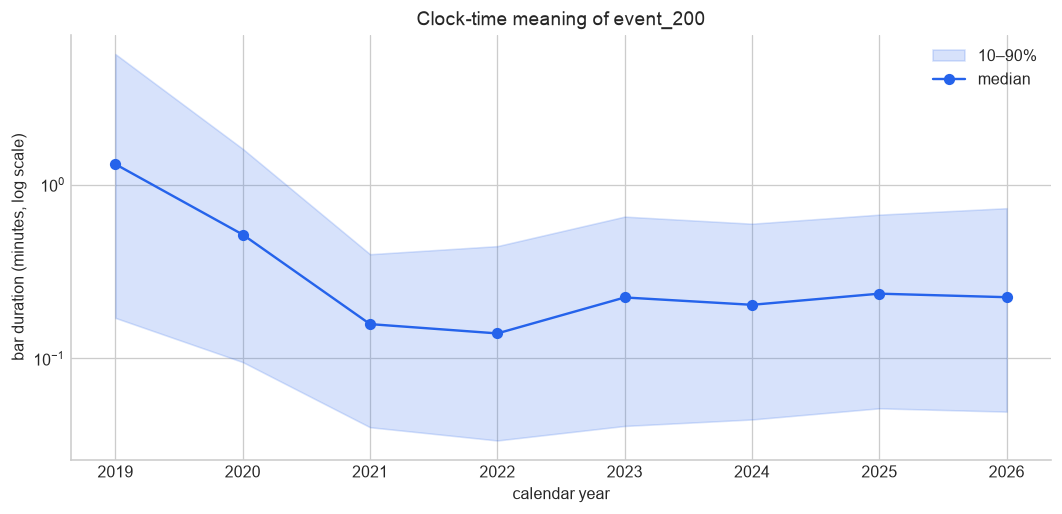

In [3]:
manifest = json.loads((CACHE_ROOT / 'cache_manifest.json').read_text())
display(manifest)

def utc_ms(value):
    return int(datetime.fromisoformat(value).replace(tzinfo=timezone.utc).timestamp() * 1_000)

development_end_ms = utc_ms(DEVELOPMENT_END)
validation_end_ms = utc_ms(VALIDATION_END)
bars = pl.read_parquet(CACHE_PATH).with_columns(
    pl.when(pl.col('end_time_ms') < development_end_ms).then(pl.lit('development'))
    .when(pl.col('end_time_ms') < validation_end_ms).then(pl.lit('validation'))
    .otherwise(pl.lit('later_exposed')).alias('period'),
    pl.from_epoch('end_time_ms', time_unit='ms').dt.year().alias('year'),
)

duration = bars.group_by('year').agg(
    pl.len().alias('bars'),
    (pl.col('duration_seconds') / 60).quantile(.10).alias('p10_minutes'),
    (pl.col('duration_seconds') / 60).median().alias('median_minutes'),
    (pl.col('duration_seconds') / 60).quantile(.90).alias('p90_minutes'),
    pl.col('event_count').median().alias('median_events'),
).sort('year')
display(duration)

fig, ax = plt.subplots(figsize=(11, 4.8))
x = duration['year'].to_numpy()
median = duration['median_minutes'].to_numpy()
ax.fill_between(x, duration['p10_minutes'], duration['p90_minutes'], alpha=.18, color='#2563eb', label='10–90%')
ax.plot(x, median, 'o-', color='#2563eb', label='median')
ax.set_yscale('log')
ax.set_xlabel('calendar year')
ax.set_ylabel('bar duration (minutes, log scale)')
ax.set_title(f'Clock-time meaning of {construction}')
ax.legend()
plt.show()

## Statistical summary

In [4]:
summary = bars.group_by('period').agg(
    pl.len().alias('bars'),
    pl.col('gross_volume').median().alias('median_volume_btc'),
    pl.col('relative_imbalance').median().alias('median_relative_imbalance'),
    pl.col('relative_activity').median().alias('median_relative_activity'),
    pl.col('normalised_imbalance').median().alias('median_normalised_net_flow'),
    pl.col('current_return_bps').std().alias('return_std_bps'),
    pl.col('normalised_signed_impact').mean().alias('mean_normalised_response'),
    (pl.col('signed_imbalance') > 0).mean().alias('buy_dominated_share'),
).sort('period')
display(summary)

period,bars,median_volume_btc,median_relative_imbalance,median_relative_activity,median_normalised_net_flow,return_std_bps,mean_normalised_response,buy_dominated_share
str,u32,f64,f64,f64,f64,f64,f64,f64
"""development""",6089736,52.684,0.321921,0.000118,0.000035,6.104408,0.007063,0.499327
"""later_exposed""",2345047,28.488,0.362183,0.000161,0.000051,3.569402,0.00806,0.49894
"""validation""",3678277,52.617,0.350583,0.000148,0.000046,3.694051,0.007929,0.496053


## Zero-origin curve families

The negative affine intercept is not carried into these candidate models. The logarithmic and power curves obey:

$$
f(0)=0.
$$

They are fitted to equal-count development-period bin means. The flexible monotonic curve is retained as a diagnostic benchmark. Curves are drawn beyond the final bin mean to the selected raw-observation quantile.

**Sell log curve:** $$\widehat I(x)=0.010833\log(1+0.58884x/3.4688e-05)$$  **Power curve:** $$\widehat I(x)=1.6815x^{0.5570}$$

**Buy log curve:** $$\widehat I(x)=0.011034\log(1+0.58884x/3.467e-05)$$  **Power curve:** $$\widehat I(x)=1.8076x^{0.5630}$$

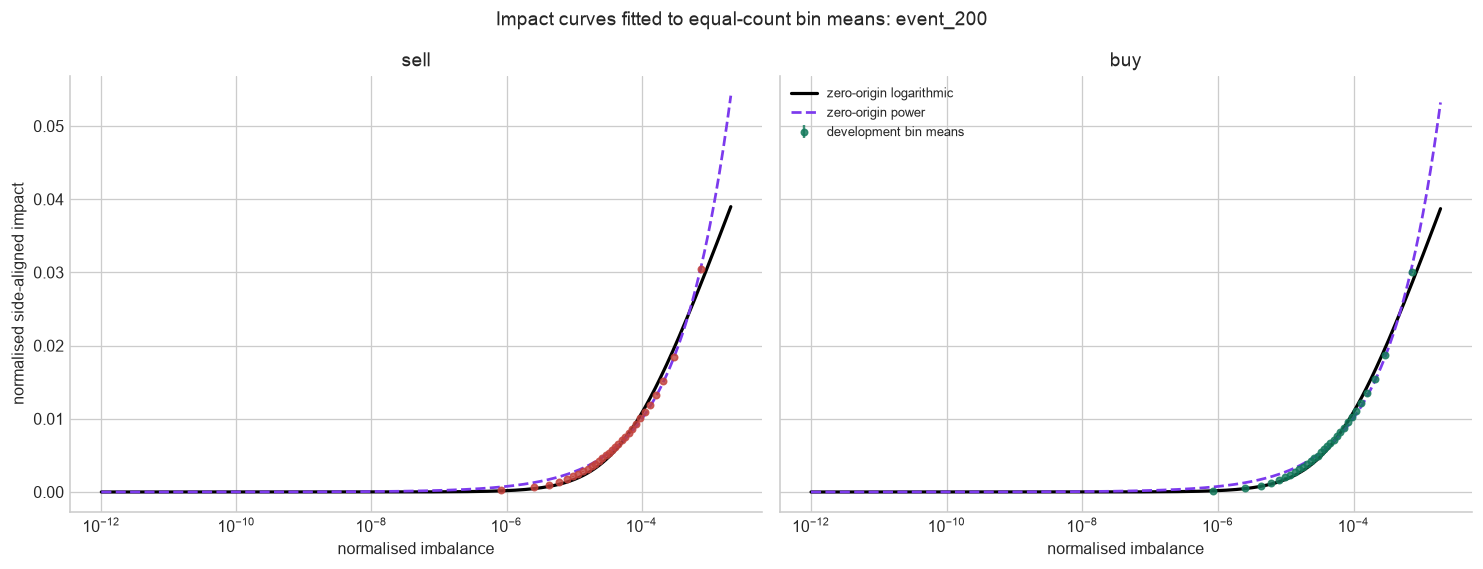

In [5]:
def binned_means(x, y, bins=30, cuts=None):
    x, y = np.asarray(x, float), np.asarray(y, float)
    keep = np.isfinite(x) & np.isfinite(y) & (x > 0)
    x, y = x[keep], y[keep]
    if cuts is None:
        cuts = np.unique(np.quantile(x, np.linspace(0, 1, bins + 1)[1:-1]))
    labels = np.digitize(x, cuts, right=True)
    rows = []
    for label in range(len(cuts) + 1):
        chosen = labels == label
        if chosen.sum() < 3:
            continue
        rows.append((x[chosen].mean(), y[chosen].mean(),
                     y[chosen].std(ddof=1) / math.sqrt(chosen.sum()), chosen.sum()))
    return np.asarray(rows), cuts

def fit_zero_log(bx, by):
    scale = float(np.median(bx))
    best = None
    for curvature in np.logspace(-3, 3, 601):
        basis = np.log1p(curvature * bx / scale)
        amplitude = max(0.0, float(np.dot(basis, by) / np.dot(basis, basis)))
        rmse = float(np.sqrt(np.mean((by - amplitude * basis) ** 2)))
        if best is None or rmse < best[0]:
            best = (rmse, amplitude, curvature, scale)
    return best

def fit_power(bx, by):
    best = None
    for exponent in np.linspace(.05, 1.50, 1_451):
        basis = bx ** exponent
        amplitude = max(0.0, float(np.dot(basis, by) / np.dot(basis, basis)))
        rmse = float(np.sqrt(np.mean((by - amplitude * basis) ** 2)))
        if best is None or rmse < best[0]:
            best = (rmse, amplitude, exponent)
    return best

x_column = 'relative_imbalance' if X_DEFINITION == 'relative_imbalance' else 'normalised_imbalance'
fits = {}
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
for ax, side_value, side_name, colour in zip(axes, [-1, 1], ['sell', 'buy'], [SELL, BUY]):
    train = bars.filter(
        (pl.col('period') == 'development') &
        (pl.col('signed_imbalance').sign() == side_value)
    ).select(x_column, 'normalised_signed_impact').drop_nulls()
    x = train[x_column].to_numpy()
    y = train['normalised_signed_impact'].to_numpy()
    bins, cuts = binned_means(x, y, CURVE_BINS)
    bx, by = bins[:, 0], bins[:, 1]
    log_rmse, log_amp, curvature, scale = fit_zero_log(bx, by)
    power_rmse, power_amp, exponent = fit_power(bx, by)
    fits[side_name] = {'cuts': cuts, 'log_amp': log_amp, 'curvature': curvature,
                       'scale': scale, 'power_amp': power_amp, 'exponent': exponent}
    grid = np.geomspace(max(float(np.nanmin(x[x > 0])), 1e-12),
                        float(np.nanquantile(x, DISPLAY_X_UPPER_QUANTILE)), 500)
    ax.errorbar(bx, by, yerr=bins[:, 2], fmt='o', ms=4, color=colour,
                alpha=.8, label='development bin means')
    ax.plot(grid, log_amp * np.log1p(curvature * grid / scale), color='black', lw=2,
            label='zero-origin logarithmic')
    ax.plot(grid, power_amp * grid ** exponent, color='#7c3aed', lw=1.7, ls='--',
            label='zero-origin power')
    ax.set_xscale('log')
    ax.set_xlabel(x_column.replace('_', ' '))
    ax.set_title(side_name)
    display(Markdown(
        rf"**{side_name.title()} log curve:** $$\widehat I(x)={log_amp:.5g}"
        rf"\log(1+{curvature:.5g}x/{scale:.5g})$$  "
        rf"**Power curve:** $$\widehat I(x)={power_amp:.5g}x^{{{exponent:.4f}}}$$"
    ))
axes[0].set_ylabel('normalised side-aligned impact')
axes[1].legend(fontsize=8)
fig.suptitle(f'Impact curves fitted to equal-count bin means: {construction}')
plt.tight_layout()
plt.show()

## Cross-scale and cross-clock curve comparison

construction,axis,side,bars,log_bin_rmse,log_amplitude,log_curvature,power_bin_rmse,power_amplitude,power_exponent
str,str,str,i64,f64,f64,f64,f64,f64,f64
"""event_1000""","""normalised_net_flow""","""buy""",1217947,0.001335,0.032807,0.489779,0.000926,3.609591,0.621
"""event_1000""","""normalised_net_flow""","""sell""",1217947,0.001759,0.033425,0.457088,0.000667,3.61403,0.625
"""event_200""","""normalised_net_flow""","""buy""",6089736,0.000561,0.011034,0.588844,0.000482,1.807632,0.563
"""event_200""","""normalised_net_flow""","""sell""",6089736,0.000682,0.010833,0.588844,0.00038,1.681463,0.557
"""event_500""","""normalised_net_flow""","""buy""",2435894,0.000997,0.020435,0.537032,0.000687,2.693488,0.595
"""event_500""","""normalised_net_flow""","""sell""",2435894,0.001285,0.020564,0.512861,0.000525,2.65001,0.596
"""time_1m""","""normalised_net_flow""","""buy""",1741128,0.001355,0.034334,0.30903,0.000535,4.235928,0.655
"""time_1m""","""normalised_net_flow""","""sell""",1741128,0.001575,0.031421,0.338844,0.000607,3.617188,0.64
"""time_2m""","""normalised_net_flow""","""buy""",870590,0.002025,0.057621,0.263027,0.00087,5.647026,0.686


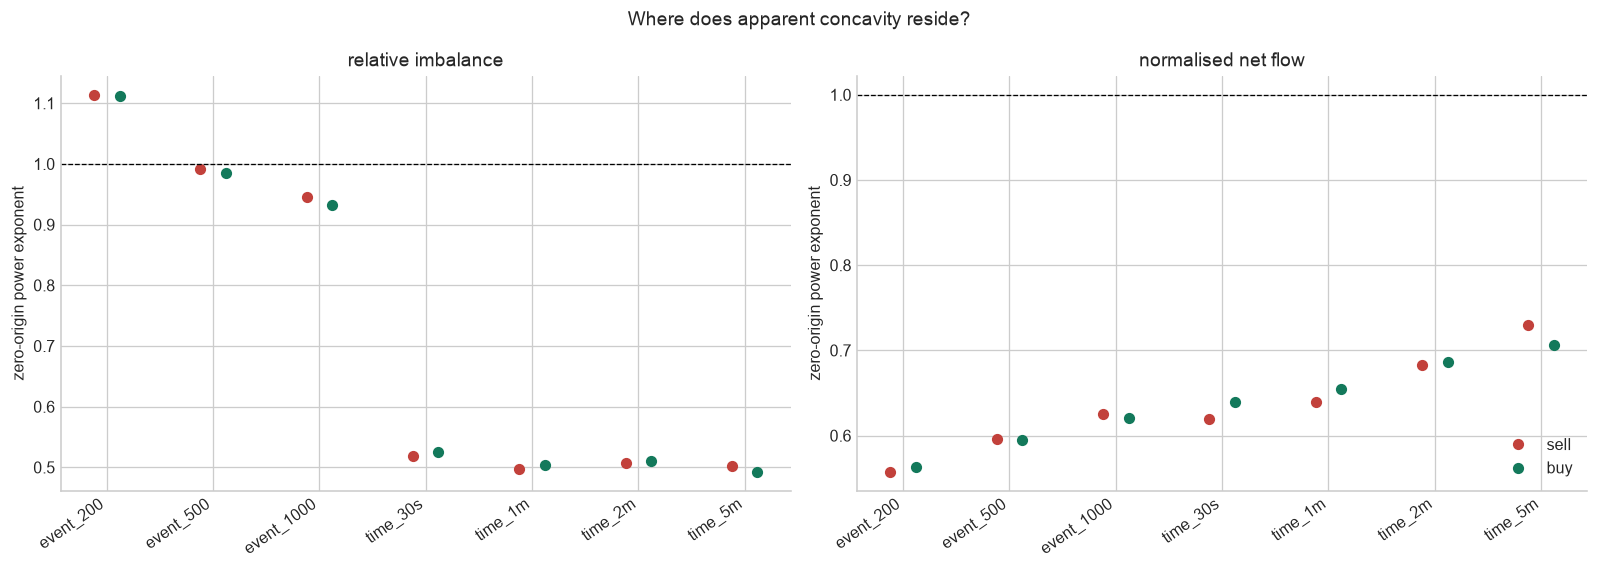

In [6]:
available_paths = {
    **{f'event_{size}': CACHE_ROOT / f'event_{size}' / 'part-000.parquet'
       for size in manifest['event_bar_sizes']},
    **{f'time_{every}': CACHE_ROOT / f'time_{every}' / 'part-000.parquet'
       for every in manifest['time_bars']},
}
comparison_rows = []
for name, path in available_paths.items():
    frame = (pl.scan_parquet(path)
             .filter(pl.col('end_time_ms') < development_end_ms)
             .select('signed_imbalance', 'relative_imbalance', 'normalised_imbalance',
                     'normalised_signed_impact')
             .collect())
    for axis_name, column in [('relative_imbalance', 'relative_imbalance'),
                              ('normalised_net_flow', 'normalised_imbalance')]:
        for side_value, side_name in [(-1, 'sell'), (1, 'buy')]:
            part = frame.filter(pl.col('signed_imbalance').sign() == side_value).select(
                column, 'normalised_signed_impact').drop_nulls()
            x = part[column].to_numpy()
            y = part['normalised_signed_impact'].to_numpy()
            bins, _ = binned_means(x, y, CURVE_BINS)
            bx, by = bins[:, 0], bins[:, 1]
            log_rmse, log_amp, curvature, scale = fit_zero_log(bx, by)
            power_rmse, power_amp, exponent = fit_power(bx, by)
            comparison_rows.append({
                'construction': name, 'axis': axis_name, 'side': side_name,
                'bars': frame.height, 'log_bin_rmse': log_rmse,
                'log_amplitude': log_amp, 'log_curvature': curvature,
                'power_bin_rmse': power_rmse, 'power_amplitude': power_amp,
                'power_exponent': exponent,
            })
    del frame
curve_comparison = pl.DataFrame(comparison_rows).sort('axis', 'construction', 'side')
display(curve_comparison)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, axis_name in zip(axes, ['relative_imbalance', 'normalised_net_flow']):
    part = curve_comparison.filter(pl.col('axis') == axis_name)
    event_constructions = sorted(
        [name for name in part['construction'].unique() if name.startswith('event_')],
        key=lambda name: int(name.split('_', 1)[1]),
    )
    time_units = {'s': 1, 'm': 60, 'h': 3_600}
    time_constructions = sorted(
        [name for name in part['construction'].unique() if name.startswith('time_')],
        key=lambda name: (
            float(name.split('_', 1)[1][:-1])
            * time_units[name.split('_', 1)[1][-1]]
        ),
    )
    constructions = event_constructions + time_constructions
    x = np.arange(len(constructions))
    for offset, (side_name, colour) in zip([-.12, .12], [('sell', SELL), ('buy', BUY)]):
        lookup = {r['construction']: r for r in part.filter(pl.col('side') == side_name).iter_rows(named=True)}
        ax.plot(x + offset, [lookup[name]['power_exponent'] for name in constructions],
                'o', color=colour, label=side_name)
    ax.axhline(1, color='black', lw=.8, ls='--')
    ax.set_xticks(x, constructions, rotation=35, ha='right')
    ax.set_ylabel('zero-origin power exponent')
    ax.set_title(axis_name.replace('_', ' '))
axes[1].legend()
fig.suptitle('Where does apparent concavity reside?')
plt.tight_layout()
plt.show()

## Statistical selection: logarithmic versus power curve

The visual comparison is formalised using frozen development-period fits. Both curves have two fitted parameters and now minimize exactly the same unweighted squared error across equal-count development bin means.

The primary criterion is **out-of-period bin calibration RMSE**, because the object of interest is the conditional mean impact curve rather than prediction of noisy individual bars. The upper-tail versions use thresholds frozen from the development sample.

The secondary criterion is paired individual-bar squared loss aggregated first by UTC day:

$$
\Delta_d=overline{(y-\widehat y_{power})^2-(y-\widehat y_{log})^2}_d.
$$

A positive value favours the logarithmic curve. Day-level aggregation prevents millions of serially related bars from being treated as independent observations. Both the size of the loss improvement and its day-block standard error are reported; statistical significance alone is not sufficient.

construction,side,period,tail_quantile,observations,days,log_test_bin_rmse,power_test_bin_rmse,bar_mse_improvement_fraction,daily_power_minus_log_mse,daily_loss_difference_t
str,str,str,f64,i64,i64,f64,f64,f64,f64,f64
"""event_1000""","""buy""","""validation_2023""",0.0,173421,365,0.000995,0.001209,-0.014149,-0.000013,-3.097224
"""event_1000""","""buy""","""validation_2023""",0.8,46374,365,0.001891,0.001809,-0.031726,-0.000025,-3.980727
"""event_1000""","""buy""","""validation_2023""",0.9,24131,365,0.002291,0.002428,-0.044758,-0.000037,-4.421514
"""event_1000""","""buy""","""validation_2023""",0.95,12042,363,0.002069,0.00299,-0.063406,-0.000057,-4.458164
"""event_1000""","""sell""","""validation_2023""",0.0,177438,365,0.001055,0.001315,-0.014201,-0.000013,-4.252905
"""event_1000""","""sell""","""validation_2023""",0.8,46300,365,0.002174,0.001362,-0.033765,-0.000029,-5.70473
"""event_1000""","""sell""","""validation_2023""",0.9,23370,365,0.002696,0.001704,-0.048423,-0.00005,-5.710863
"""event_1000""","""sell""","""validation_2023""",0.95,11509,360,0.003106,0.002276,-0.069136,-0.000102,-4.552312
"""event_200""","""buy""","""validation_2023""",0.0,870442,365,0.000597,0.000708,-0.016184,-0.000004,-2.977829


period,tail_quantile,event_side_cells,log_bin_wins,log_bar_loss_wins,median_bin_rmse_improvement,median_bar_mse_improvement
str,f64,u32,u32,u32,f64,f64
"""validation_2023""",0.0,6,6,0,0.166957,-0.014175
"""validation_2023""",0.8,6,1,0,-0.171912,-0.032745
"""validation_2023""",0.9,6,1,0,-0.529169,-0.046609
"""validation_2023""",0.95,6,1,0,-0.504723,-0.069377
"""validation_2024""",0.0,6,4,2,0.010018,-0.002854
"""validation_2024""",0.8,6,3,0,-0.00918,-0.007862
"""validation_2024""",0.9,6,6,0,0.068918,-0.004536
"""validation_2024""",0.95,6,6,4,0.144378,0.012685


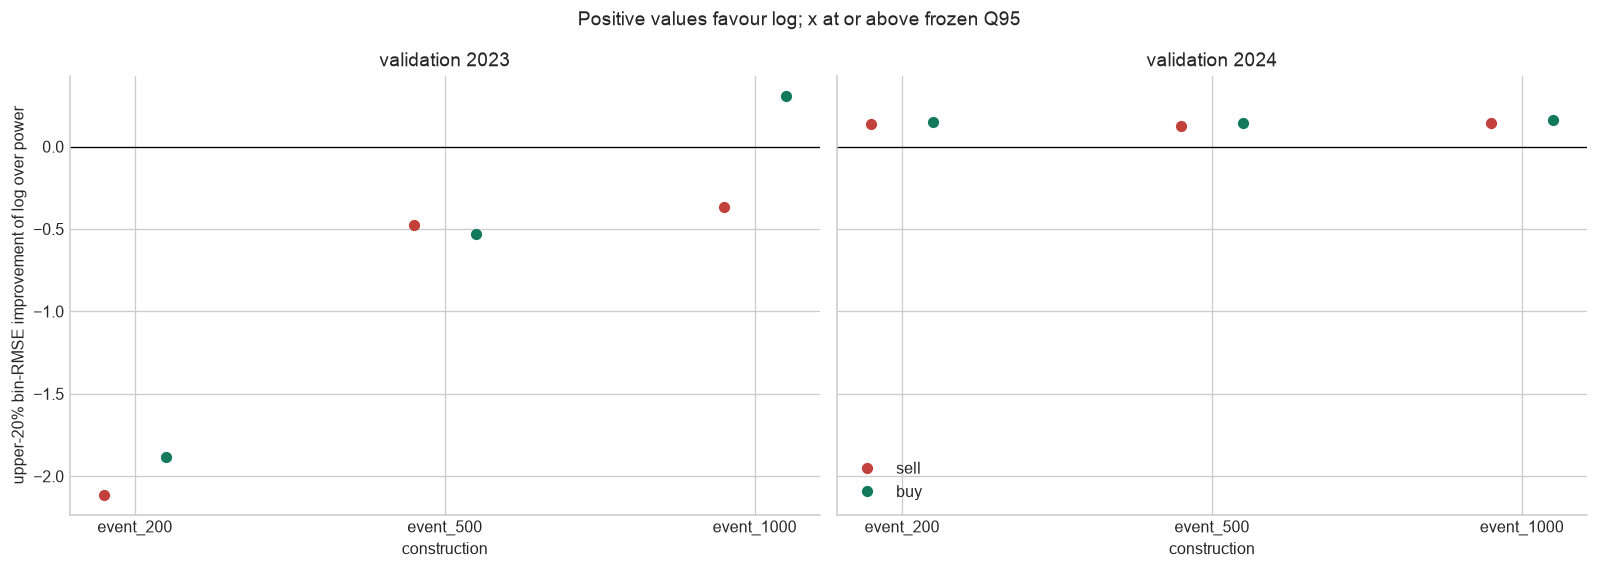

In [7]:
def calibration_bin_rmse(x, y, prediction, cuts, selected):
    labels = np.digitize(x, cuts, right=True)
    residuals, weights = [], []
    for label in range(len(cuts) + 1):
        chosen = selected & (labels == label)
        if chosen.sum() < 3:
            continue
        residuals.append(float(np.mean(y[chosen] - prediction[chosen])))
        weights.append(int(chosen.sum()))
    residuals = np.asarray(residuals)
    weights = np.asarray(weights)
    if len(residuals) == 0:
        return np.nan, np.nan, 0
    return (
        float(np.sqrt(np.mean(residuals ** 2))),
        float(np.sqrt(np.average(residuals ** 2, weights=weights))),
        len(residuals),
    )

evaluation_periods = {
    'validation_2023': (utc_ms('2023-01-01'), utc_ms('2024-01-01')),
    'validation_2024': (utc_ms('2024-01-01'), utc_ms('2025-01-01')),
    'later_exposed': (utc_ms('2025-01-01'), utc_ms('2026-06-01')),
}
tail_quantiles = (0.0, 0.80, 0.90, 0.95)
selection_rows = []

for name, path in available_paths.items():
    frame = (pl.scan_parquet(path)
             .select('end_time_ms', 'signed_imbalance', 'normalised_imbalance',
                     'normalised_signed_impact')
             .collect())
    time = frame['end_time_ms'].to_numpy()
    side = frame['signed_imbalance'].sign().to_numpy()
    x = frame['normalised_imbalance'].to_numpy()
    y = frame['normalised_signed_impact'].to_numpy()
    valid = np.isfinite(x) & np.isfinite(y) & (x > 0) & (side != 0)

    for side_value, side_name in [(-1, 'sell'), (1, 'buy')]:
        training = valid & (side == side_value) & (time < development_end_ms)
        training_bins, frozen_bin_cuts = binned_means(x[training], y[training], CURVE_BINS)
        bx, by = training_bins[:, 0], training_bins[:, 1]
        log_train_rmse, log_amp, curvature, scale = fit_zero_log(bx, by)
        power_train_rmse, power_amp, exponent = fit_power(bx, by)

        log_prediction = log_amp * np.log1p(curvature * x / scale)
        power_prediction = power_amp * x ** exponent

        for period_name, (period_start, period_end) in evaluation_periods.items():
            period_mask = (
                valid & (side == side_value)
                & (time >= period_start) & (time < period_end)
            )
            for tail_quantile in tail_quantiles:
                tail_cut = (
                    0.0 if tail_quantile == 0
                    else float(np.quantile(x[training], tail_quantile))
                )
                selected = period_mask & (x >= tail_cut)
                log_loss = (y[selected] - log_prediction[selected]) ** 2
                power_loss = (y[selected] - power_prediction[selected]) ** 2
                days = time[selected] // 86_400_000
                daily_loss = (
                    pl.DataFrame({
                        'day': days,
                        'log_loss': log_loss,
                        'power_loss': power_loss,
                    })
                    .group_by('day')
                    .agg(
                        pl.col('log_loss').mean(),
                        pl.col('power_loss').mean(),
                    )
                    .with_columns(
                        (pl.col('power_loss') - pl.col('log_loss')).alias('difference')
                    )
                )
                difference = daily_loss['difference'].to_numpy()
                mean_difference = float(np.mean(difference))
                difference_se = (
                    float(np.std(difference, ddof=1) / np.sqrt(len(difference)))
                    if len(difference) > 1 else np.nan
                )
                log_bin_rmse, log_weighted_bin_rmse, bins_used = calibration_bin_rmse(
                    x, y, log_prediction, frozen_bin_cuts, selected
                )
                power_bin_rmse, power_weighted_bin_rmse, _ = calibration_bin_rmse(
                    x, y, power_prediction, frozen_bin_cuts, selected
                )
                log_mse = float(np.mean(log_loss))
                power_mse = float(np.mean(power_loss))
                selection_rows.append({
                    'construction': name,
                    'side': side_name,
                    'period': period_name,
                    'tail_quantile': tail_quantile,
                    'training_tail_cut': tail_cut,
                    'observations': int(selected.sum()),
                    'days': len(difference),
                    'bins_used': bins_used,
                    'log_train_bin_rmse': log_train_rmse,
                    'power_train_bin_rmse': power_train_rmse,
                    'log_test_bin_rmse': log_bin_rmse,
                    'power_test_bin_rmse': power_bin_rmse,
                    'log_weighted_test_bin_rmse': log_weighted_bin_rmse,
                    'power_weighted_test_bin_rmse': power_weighted_bin_rmse,
                    'log_bar_rmse': float(np.sqrt(log_mse)),
                    'power_bar_rmse': float(np.sqrt(power_mse)),
                    'bar_mse_improvement_fraction': (
                        (power_mse - log_mse) / power_mse
                        if power_mse > 0 else np.nan
                    ),
                    'daily_power_minus_log_mse': mean_difference,
                    'daily_loss_difference_se': difference_se,
                    'daily_loss_difference_t': (
                        mean_difference / difference_se
                        if difference_se > 0 else np.nan
                    ),
                    'log_curvature': curvature,
                    'power_exponent': exponent,
                })
    del frame, time, side, x, y

model_selection = pl.DataFrame(selection_rows).sort(
    'period', 'construction', 'side', 'tail_quantile'
)
event_validation = model_selection.filter(
    pl.col('construction').is_in(['event_200', 'event_500', 'event_1000'])
    & pl.col('period').is_in(['validation_2023', 'validation_2024'])
    & pl.col('tail_quantile').is_in([0.0, 0.80, 0.90, 0.95])
).select(
    'construction', 'side', 'period', 'tail_quantile', 'observations', 'days',
    'log_test_bin_rmse', 'power_test_bin_rmse',
    'bar_mse_improvement_fraction', 'daily_power_minus_log_mse',
    'daily_loss_difference_t',
)
display(event_validation)

model_choice_summary = event_validation.with_columns(
    (
        (pl.col('power_test_bin_rmse') - pl.col('log_test_bin_rmse'))
        / pl.col('power_test_bin_rmse')
    ).alias('tail_bin_rmse_improvement'),
    (pl.col('log_test_bin_rmse') < pl.col('power_test_bin_rmse'))
    .alias('log_wins_equal_bin_calibration'),
    (pl.col('daily_power_minus_log_mse') > 0)
    .alias('log_wins_paired_bar_loss'),
).group_by('period', 'tail_quantile').agg(
    pl.len().alias('event_side_cells'),
    pl.col('log_wins_equal_bin_calibration').sum().alias('log_bin_wins'),
    pl.col('log_wins_paired_bar_loss').sum().alias('log_bar_loss_wins'),
    pl.col('tail_bin_rmse_improvement').median().alias('median_bin_rmse_improvement'),
    pl.col('bar_mse_improvement_fraction').median().alias('median_bar_mse_improvement'),
).sort('period', 'tail_quantile')
display(model_choice_summary)

plot_data = event_validation.filter(
    pl.col('tail_quantile') == MODEL_COMPARISON_TAIL
).with_columns(
    (
        (pl.col('power_test_bin_rmse') - pl.col('log_test_bin_rmse'))
        / pl.col('power_test_bin_rmse')
    ).alias('tail_bin_rmse_improvement')
)
event_order = ['event_200', 'event_500', 'event_1000']
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, period_name in zip(axes, ['validation_2023', 'validation_2024']):
    part = plot_data.filter(pl.col('period') == period_name)
    x_position = np.arange(len(event_order))
    for offset, (side_name, colour) in zip([-.10, .10], [('sell', SELL), ('buy', BUY)]):
        lookup = {row['construction']: row for row in part.filter(
            pl.col('side') == side_name).iter_rows(named=True)}
        ax.plot(
            x_position + offset,
            [lookup[name]['tail_bin_rmse_improvement'] for name in event_order],
            'o', color=colour, label=side_name,
        )
    ax.axhline(0, color='black', lw=.8)
    ax.set_xticks(x_position, event_order)
    ax.set_title(period_name.replace('_', ' '))
    ax.set_xlabel('construction')
axes[0].set_ylabel('upper-20% bin-RMSE improvement of log over power')
axes[1].legend()
fig.suptitle(
    f'Positive values favour log; x at or above frozen Q{int(100 * MODEL_COMPARISON_TAIL)}'
)
plt.tight_layout()
plt.show()

## Low-imbalance behaviour

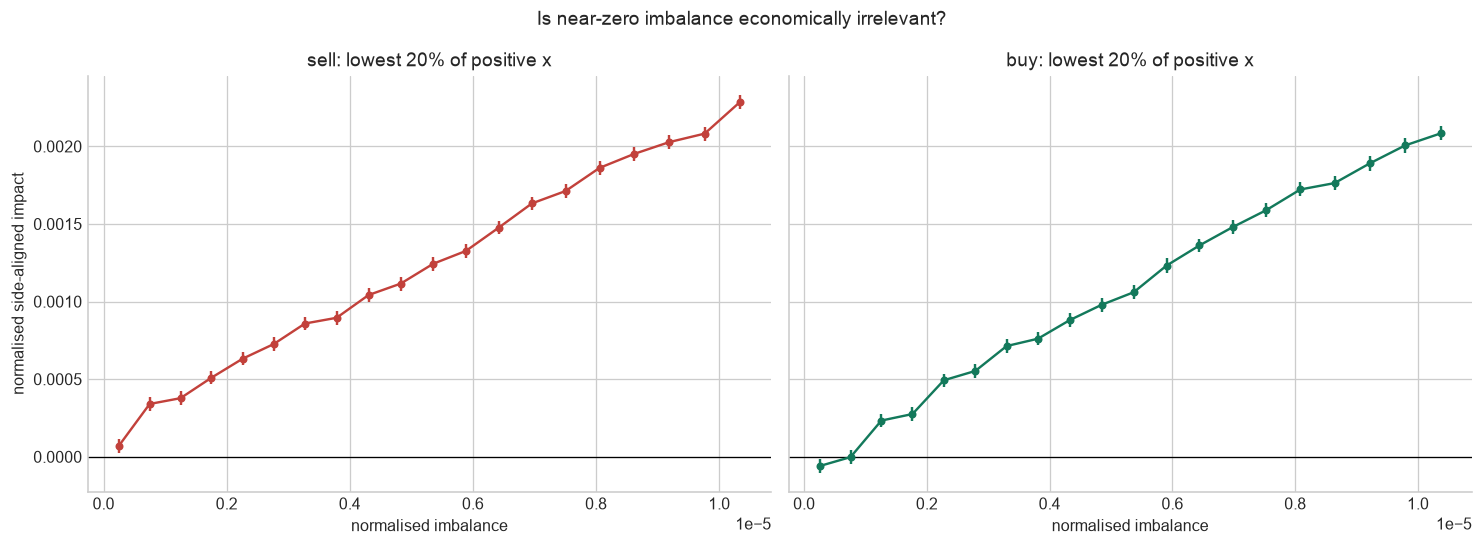

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), sharey=True)
for ax, side_value, side_name, colour in zip(axes, [-1, 1], ['sell', 'buy'], [SELL, BUY]):
    part = bars.filter(
        (pl.col('period') == 'development') &
        (pl.col('signed_imbalance').sign() == side_value)
    ).select(x_column, 'normalised_signed_impact').drop_nulls()
    x, y = part[x_column].to_numpy(), part['normalised_signed_impact'].to_numpy()
    upper = np.quantile(x[x > 0], .20)
    chosen = (x > 0) & (x <= upper)
    bins, _ = binned_means(x[chosen], y[chosen], 20)
    ax.errorbar(bins[:, 0], bins[:, 1], yerr=bins[:, 2], fmt='o-', color=colour, ms=4)
    ax.axhline(0, color='black', lw=.8)
    ax.set_xlabel(x_column.replace('_', ' '))
    ax.set_title(f'{side_name}: lowest 20% of positive x')
axes[0].set_ylabel('normalised side-aligned impact')
fig.suptitle('Is near-zero imbalance economically irrelevant?')
plt.tight_layout()
plt.show()

## Relative imbalance × activity surface

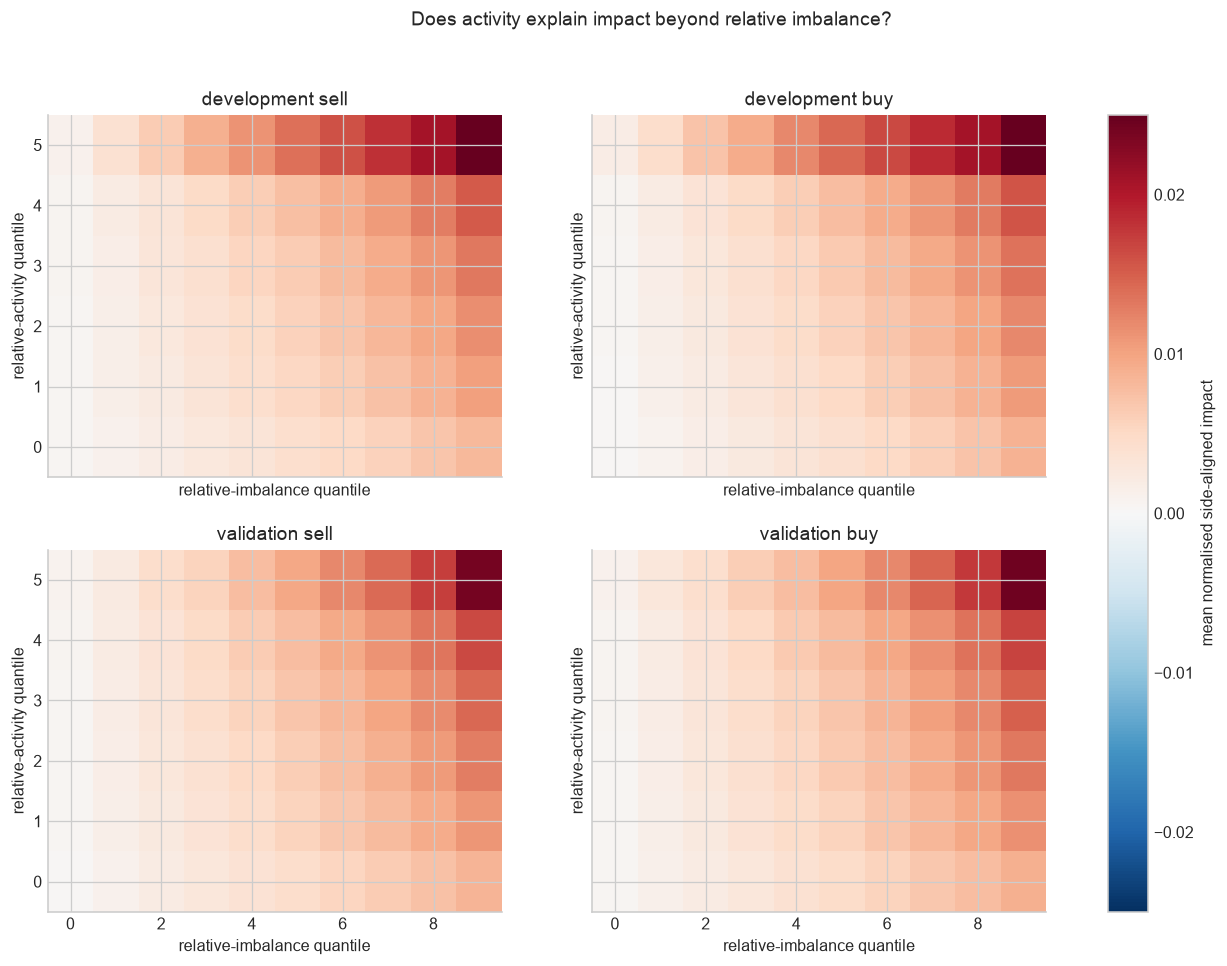

In [9]:
development = bars.filter(pl.col('period') == 'development')
imbalance_cuts = development['relative_imbalance'].drop_nulls().quantile(
    np.linspace(0, 1, SURFACE_IMBALANCE_BINS + 1)[1:-1], interpolation='linear'
) if False else np.quantile(development['relative_imbalance'].drop_nulls().to_numpy(),
                            np.linspace(0, 1, SURFACE_IMBALANCE_BINS + 1)[1:-1])
activity_cuts = np.quantile(development['relative_activity'].drop_nulls().to_numpy(),
                            np.linspace(0, 1, SURFACE_ACTIVITY_BINS + 1)[1:-1])

def impact_surface(frame, side_value):
    part = frame.filter(pl.col('signed_imbalance').sign() == side_value).select(
        'relative_imbalance', 'relative_activity', 'normalised_signed_impact'
    ).drop_nulls()
    ix = np.digitize(part['relative_imbalance'].to_numpy(), imbalance_cuts, right=True)
    ia = np.digitize(part['relative_activity'].to_numpy(), activity_cuts, right=True)
    y = part['normalised_signed_impact'].to_numpy()
    result = np.full((SURFACE_ACTIVITY_BINS, SURFACE_IMBALANCE_BINS), np.nan)
    for a in range(SURFACE_ACTIVITY_BINS):
        for i in range(SURFACE_IMBALANCE_BINS):
            chosen = (ia == a) & (ix == i)
            if chosen.any():
                result[a, i] = np.mean(y[chosen])
    return result

fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True, sharey=True)
surfaces = []
for row, period in enumerate(['development', 'validation']):
    for column, (side_value, side_name) in enumerate([(-1, 'sell'), (1, 'buy')]):
        surface = impact_surface(bars.filter(pl.col('period') == period), side_value)
        surfaces.append(surface)
limit = max(np.nanmax(np.abs(surface)) for surface in surfaces)
for ax, surface, title in zip(axes.flat, surfaces,
                              ['development sell', 'development buy', 'validation sell', 'validation buy']):
    image = ax.imshow(surface, origin='lower', aspect='auto', cmap='RdBu_r', vmin=-limit, vmax=limit)
    ax.set_title(title)
    ax.set_xlabel('relative-imbalance quantile')
    ax.set_ylabel('relative-activity quantile')
fig.colorbar(image, ax=axes, label='mean normalised side-aligned impact')
fig.suptitle('Does activity explain impact beyond relative imbalance?')
plt.show()

## Frozen-curve calibration through time

year,side,observations,mean_residual,rmse,x_median,y_mean
i64,str,i64,f64,f64,f64,f64
2019,"""sell""",36715,0.001041,0.03463,0.000276,0.020358
2020,"""sell""",353155,0.00028,0.017205,0.00011,0.012839
2021,"""sell""",1348582,0.000403,0.009254,0.00003,0.006257
2022,"""sell""",1310407,0.000021,0.009591,0.00003,0.005946
2023,"""sell""",883856,0.000285,0.010914,0.000047,0.008127
2024,"""sell""",969801,-0.000106,0.010877,0.000046,0.007601
2025,"""sell""",843856,-0.000415,0.011874,0.000053,0.008049
2026,"""sell""",331153,-0.000196,0.012199,0.000049,0.00805
2019,"""buy""",34872,0.001877,0.03256,0.000261,0.020824


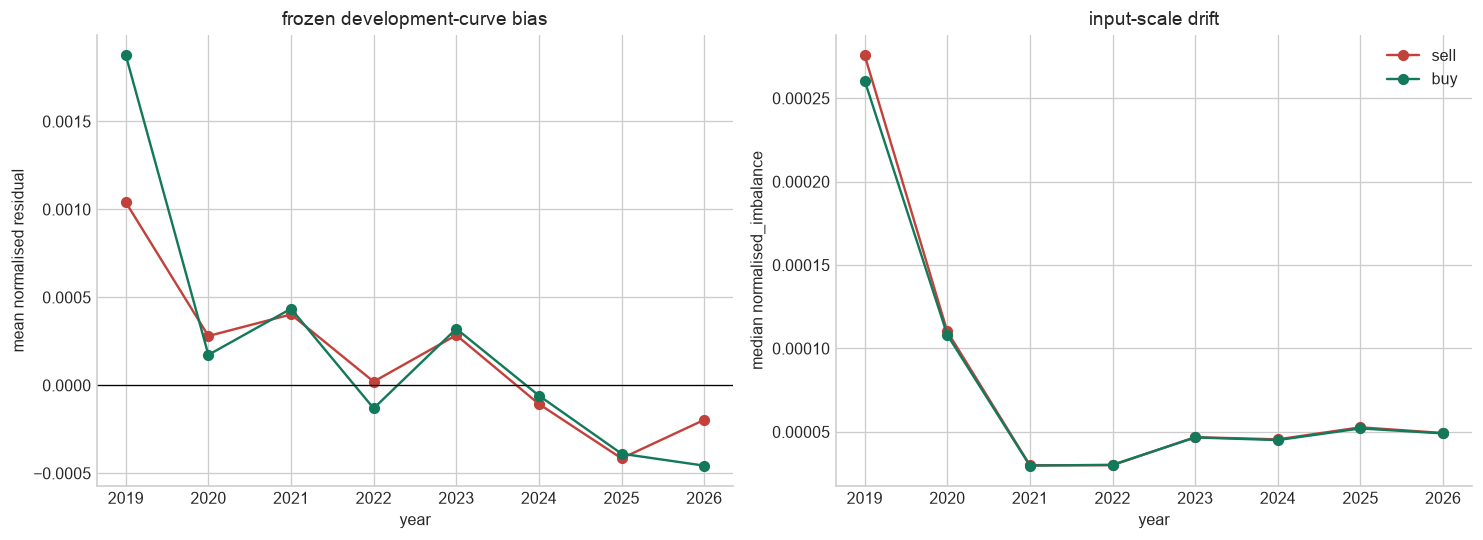

In [10]:
rows = []
for side_value, side_name in [(-1, 'sell'), (1, 'buy')]:
    fit = fits[side_name]
    for year in sorted(bars['year'].unique()):
        part = bars.filter(
            (pl.col('year') == year) & (pl.col('signed_imbalance').sign() == side_value)
        ).select(x_column, 'normalised_signed_impact').drop_nulls()
        x, y = part[x_column].to_numpy(), part['normalised_signed_impact'].to_numpy()
        pred = fit['log_amp'] * np.log1p(fit['curvature'] * x / fit['scale'])
        rows.append({'year': int(year), 'side': side_name, 'observations': len(x),
                     'mean_residual': float(np.mean(y - pred)),
                     'rmse': float(np.sqrt(np.mean((y - pred) ** 2))),
                     'x_median': float(np.median(x)),
                     'y_mean': float(np.mean(y))})
calibration = pl.DataFrame(rows)
display(calibration)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
for side_name, colour in [('sell', SELL), ('buy', BUY)]:
    part = calibration.filter(pl.col('side') == side_name).sort('year')
    axes[0].plot(part['year'], part['mean_residual'], 'o-', color=colour, label=side_name)
    axes[1].plot(part['year'], part['x_median'], 'o-', color=colour, label=side_name)
axes[0].axhline(0, color='black', lw=.8)
axes[0].set_title('frozen development-curve bias')
axes[0].set_ylabel('mean normalised residual')
axes[1].set_title('input-scale drift')
axes[1].set_ylabel(f'median {x_column}')
for ax in axes:
    ax.set_xlabel('year')
axes[1].legend()
plt.tight_layout()
plt.show()

## Interpretation gate

The next decision is deliberately narrow:

1. Does the zero-origin logarithmic or power curve remain calibrated in 2023–24?
2. Does relative activity materially improve the one-dimensional curve?
3. Can annual drift be absorbed mainly by rolling input and response scales, leaving a stable master shape?
4. Are conclusions robust to event bars versus clock-time bars and to the shortest usable bar sizes?

Only after answering these questions should the selected rolling fit be used to define excess impact. June–August 2026 remains unopened during this model-selection stage.